## 활성화 함수가 필요한 이유를 보여보지!

(300, 2) (300,)
[[ 0.884408   -0.65607891]
 [ 0.07466918 -0.30576367]
 [ 0.86855581  0.63622971]]
[1 1 0 1 1 0 1 1 0 0]


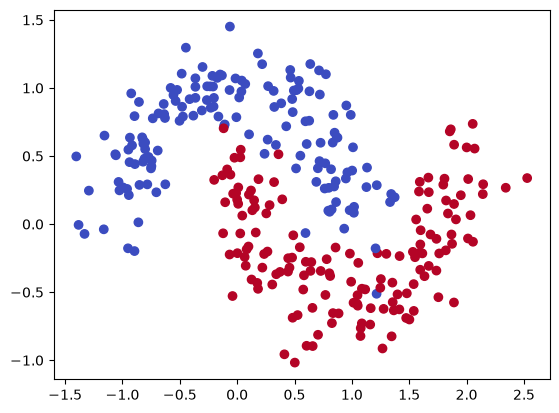

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=0)
print(X.shape, y.shape)        # (300, 2) (300,)
print(X[:3])                   # 점 3개의 좌표
print(y[:10])                  # 라벨 0/1

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.show()

위처럼, 이는 직선으로만 구분할 수 없다!
즉, 선형적인 분류로는 절대 이를 나눌 수 없음. 그렇기에 비선형적인 activate function이 필요하다

이에는 시그모이드, ReLU, Hyperbolic Tangent등이 필요하다.

이는 결국 선형 분리 불가능(non-linearly separable) 문제로 연결되고, 이것이 바로 은닉층이 필요한 이유이다.


### 순전파 코드를 넘파이로 짜서 확인해보자!

In [ ]:
import numpy as np

y = y.reshape(-1, 1) # row 개수는 알아서 계산해라

rng = np.random.default_rng(0) 
d, h = 2, 8 # 입력 2차원, 은닉층 뉴런 8개

W1 = rng.standard_normal((d, h)) * 0.1 # 표준 정규 분포에서 랜덤값 뽑기, 0.1 곱하는 이유는 시그모이드 함수에 맞추기 위해서
b1 = np.zeros((1, h)) # bias를 준다
W2 = rng.standard_normal((h, 1)) * 0.1 # 위와 같다.
b2 = np.zeros((1, 1)) # 은닉층 출력이 하나이므로, 이에 맞춘다

Z1 = X @ W1 + b1               # (300,2)@(2,8) → (300,8), broadcasting 이용!
A1 = np.maximum(0, Z1)         # ReLU
Z2 = A1 @ W2 + b2              # (300,8)@(8,1) → (300,1)
A2 = 1 / (1 + np.exp(-Z2))     # sigmoid

print(Z1.shape, A1.shape, Z2.shape, A2.shape)

eps = 1e-12 # log 0은 존재하지 않기 때문에
loss = -np.mean(y*np.log(A2+eps) + (1-y)*np.log(1-A2+eps)) # Binary Classification에서 가장 많이 사용된다.
print("loss =", loss)

# 파이토치로는 더 쉽게 구현할 수 있다!

(300, 8) (300, 8) (300, 1) (300, 1)
loss = 0.6933307351733705


## loss 코드 부분에 대한 더 자세한 정리

```python
loss = -np.mean(y*np.log(A2+eps) + (1-y)*np.log(1-A2+eps))
```

여기서 y는 정답(Label)을 의미한다.

이때 정답이 있으므로 이 과정은 지도학습에 해당된다.

예를 들어
```python
y =
[[1],
 [0],
 [1],
 [1],
 [0]]
 ```
이다.

A2는 모델이 예측한 확률에 해당된다.

### 왜 log를 사용할까?

손실 함수는 틀리면, 벌을 주고 맞으면 거의 벌주지 않는 함수이다.

즉 정답이 1인데, 모델이 99%라고 예측하면 Loss는 거의 0에 가깝다

반대로 1인데, 모델이 1%라고 예측하면 Loss는 매우 커진다.

그렇기에 식은 두 개로 나눠진다. 정답이 1인 경우 "-log(A2)" 정답이 0인 경우 "-log(1-A2)"

if 쓰기 귀찮으니까, 1-y, y로 한 것!


### eps는 왜 넣을까?

eps = 0.000000000001 이라는 매우 작은 숫자!

손실 함수 안에는 np.log(A2)가 있다.

만약 A2 = 0 이면 log(0)이 된다.

이는 발산하므로 이를 막기 위한 것이라고 보면 된다.

### PINN과 연결하자면?

지금 코드는 정답이 있고, Label과 비교하는 지도학습!

PINN에는 대부분 정답이 없고, PDE를 만족해야 한다는 조건을 갖는다.

그렇기에 PyTorch의 자동 미분을 이용해서 PDE의 왼쪽과 오른쪽이 같은지 비교한다.

즉, “정답(Label) 대신 물리 법칙(PDE)을 정답으로 사용하는 신경망”이라고 볼 수 있다.
